# Tutorial 13 — (5,5) carbon nanotube: ballistic transport

The waw-native reimagining of Wannier90 tutorial 13 — the tutorial that introduced **"bulk" ballistic transport** to the project (`waw.analysis.transport_bulk`, the same Lopez-Sancho decimation used in the aluminium-chain bonus notebook, applied here to a real, chemically-realistic periodic 1-D conductor). A (5,5) armchair nanotube, 20 C atoms/cell, is disentangled from 80 bands down to 50 MLWFs (20 radial $p_z$ $\pi$ orbitals + 30 $\sigma$-bond $s$ orbitals), then its Landauer transmission is computed directly from the Wannier $H(R)$.

In [1]:
import os, sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

# locate the repo root (the folder containing the `waw` package), so the
# notebook runs from anywhere
HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import waw
from waw.interfaces import quantum_espresso as qe   # the direct-input QE driver
from waw.interfaces.ase.driver import wannierize
from waw.units import BOHR_TO_ANG, HARTREE_TO_EV
from waw.vis import plot_bands, BandSeries

PSEUDO_DIR = REPO / 'workflows' / 'pseudos'   # shared across workflows/, not w90tutorial-specific
NCORES = 16
waw.set_num_threads(NCORES)                  # use many cores for waw's batched linear algebra
print('waw', 'threads =', waw.get_num_threads(), '| repo', REPO)

waw threads = 16 | repo /aims_data/miguel/nas-data001/claude/wannier


### 1. Structure and converged DFT
The tube sits in a $16\times16$ Å box (vacuum around the tube) with a $2.4628$ Å period along $z$ (the tube axis) — a $1\times1\times5$ $k$-mesh (only the periodic direction is sampled). 82 bands (80 target + 2 Davidson buffer, excluded afterwards). The projections are the tutorial's own: a **radial** $p_z$ on every atom (zaxis pointing outward from the tube axis — the $\pi$ system) plus an $s$ orbital on each of the 30 C-C $\sigma$ bonds in the unit cell.

In [2]:
from ase import Atoms

POSITIONS = [
    (3.378034, -0.712837, -0.615700), (3.378034, 0.712837, -0.615700),
    (1.717153, 2.957521, -0.615700), (0.359290, 3.390555, -0.615700),
    (-2.303060, 2.540326, -0.615700), (-3.151822, 1.395019, -0.615700),
    (-3.151822, -1.395019, -0.615700), (-2.303060, -2.540326, -0.615700),
    (0.359290, -3.390555, -0.615700), (1.717153, -2.957521, -0.615700),
    (3.151822, -1.395019, 0.615700), (3.151822, 1.395019, 0.615700),
    (2.303060, 2.540326, 0.615700), (-0.359290, 3.390555, 0.615700),
    (-1.717153, 2.957521, 0.615700), (-3.378034, 0.712837, 0.615700),
    (-3.378034, -0.712837, 0.615700), (-1.717153, -2.957521, 0.615700),
    (-0.359290, -3.390555, 0.615700), (2.303060, -2.540326, 0.615700),
]   # 20 C atoms, Angstrom (Cartesian)
atoms = Atoms('C20', positions=POSITIONS, cell=[[16, 0, 0], [0, 16, 0], [0, 0, 2.4628]], pbc=True)
MP_GRID = (1, 1, 5)
WORK = HERE / 'runs' / 'cnt55'
SMEAR = dict(occupations='smearing', smearing='cold', degauss=0.03)

# 20 radial pz (pi system): (cx,cy,cz, zx,zy,zz, xx,xy,xz) Angstrom
PZ_SPECS = [
    (3.3780, -0.7128, -0.6157, 3.3780, -0.7128, 0.0, 0, 0, 1), (3.3780, 0.7128, -0.6157, 3.3780, 0.7128, 0.0, 0, 0, 1),
    (1.7172, 2.9575, -0.6157, 1.7172, 2.9575, 0.0, 0, 0, 1), (0.3593, 3.3906, -0.6157, 0.3593, 3.3906, 0.0, 0, 0, 1),
    (-2.3031, 2.5403, -0.6157, -2.3031, 2.5403, 0.0, 0, 0, 1), (-3.1518, 1.3950, -0.6157, -3.1518, 1.3950, 0.0, 0, 0, 1),
    (-3.1518, -1.3950, -0.6157, -3.1518, -1.3950, 0.0, 0, 0, 1), (-2.3031, -2.5403, -0.6157, -2.3031, -2.5403, 0.0, 0, 0, 1),
    (0.3593, -3.3906, -0.6157, 0.3593, -3.3906, 0.0, 0, 0, 1), (1.7172, -2.9575, -0.6157, 1.7172, -2.9575, 0.0, 0, 0, 1),
    (3.1518, -1.3950, 0.6157, 3.1518, -1.3950, 0.0, 0, 0, 1), (3.1518, 1.3950, 0.6157, 3.1518, 1.3950, 0.0, 0, 0, 1),
    (2.3031, 2.5403, 0.6157, 2.3031, 2.5403, 0.0, 0, 0, 1), (-0.3593, 3.3906, 0.6157, -0.3593, 3.3906, 0.0, 0, 0, 1),
    (-1.7172, 2.9575, 0.6157, -1.7172, 2.9575, 0.0, 0, 0, 1), (-3.3780, 0.7128, 0.6157, -3.3780, 0.7128, 0.0, 0, 0, 1),
    (-3.3780, -0.7128, 0.6157, -3.3780, -0.7128, 0.0, 0, 0, 1), (-1.7172, -2.9575, 0.6157, -1.7172, -2.9575, 0.0, 0, 0, 1),
    (-0.3593, -3.3906, 0.6157, -0.3593, -3.3906, 0.0, 0, 0, 1), (2.3031, -2.5403, 0.6157, 2.3031, -2.5403, 0.0, 0, 0, 1),
]
# 30 sigma-bond-centred s orbitals: (cx,cy,cz) Angstrom
S_CENTRES = [
    (-2.7274, -1.9677, -0.6157), (1.0382, -3.1740, -0.6157), (3.3780, 0.0000, -0.6157),
    (1.0382, 3.1740, -0.6157), (-2.7274, 1.9677, -0.6157), (-3.2649, -1.0539, 0.0),
    (-2.0101, -2.7489, 0.0), (0.0000, -3.3906, 0.0), (2.0101, -2.7489, 0.0),
    (3.2649, -1.0539, 0.0), (3.2649, 1.0539, 0.0), (2.0101, 2.7489, 0.0),
    (0.0000, 3.3906, 0.0), (-2.0101, 2.7489, 0.0), (-3.2649, 1.0539, 0.0),
    (-1.0382, -3.1740, 0.6157), (2.7274, -1.9677, 0.6157), (2.7274, 1.9677, 0.6157),
    (-1.0382, 3.1740, 0.6157), (-3.3780, 0.0000, 0.6157), (-3.2649, -1.0539, 1.2314),
    (-2.0101, -2.7489, 1.2314), (0.0000, -3.3906, 1.2314), (2.0101, -2.7489, 1.2314),
    (3.2649, -1.0539, 1.2314), (3.2649, 1.0539, 1.2314), (2.0101, 2.7489, 1.2314),
    (0.0000, 3.3906, 1.2314), (-2.0101, 2.7489, 1.2314), (-3.2649, 1.0539, 1.2314),
]

inv_cell_T = np.linalg.inv(atoms.cell[:].T)
projections = []
for cx, cy, cz, zx, zy, zz, xx, xy, xz in PZ_SPECS:
    frac = tuple(inv_cell_T @ np.array([cx, cy, cz]))
    projections.append((frac, 1, 1, 1, (zx, zy, zz), (xx, xy, xz), 1.0))   # pz, custom radial zaxis
for cx, cy, cz in S_CENTRES:
    frac = tuple(inv_cell_T @ np.array([cx, cy, cz]))
    projections.append((frac, 0, 1, 1, (0., 0., 1.), (1., 0., 0.), 1.0))    # s

ov = qe.generate_overlaps(
    atoms, MP_GRID, WORK, 'cnt55',
    ecutwfc=30, scf_kpts=(1, 1, 5), nbnd=82, num_wann=50,
    exclude_bands=[81, 82], projections=projections, system_extra=SMEAR,
    pseudopotentials={'C': 'C.upf'}, pseudo_dir=PSEUDO_DIR, ncores=NCORES,
    rerun_scf=False,          # reuse a completed SCF in runs/cnt55/ if present
)
print('overlap shapes:', {k: np.shape(v) for k, v in ov.items()
                          if k in ('mmn', 'amn', 'eig')})

overlap shapes: {'mmn': (5, 6, 80, 80), 'amn': (5, 80, 50), 'eig': (5, 80)}


### 2. Disentangle + Wannierise
Frozen window to 1.8 eV, outer window to 6.3 eV — the same values Wannier90 tutorial 13 uses.

In [3]:
result = wannierize(
    atoms, MP_GRID, ov['kpts'],
    mmn=ov['mmn'], amn=ov['amn'], eig=ov['eig'],
    nnkpts=ov['nnkpts'], g_vectors=ov['g_vectors'],
    nw=50, outer_window=(-1e3, 6.3), frozen_window=(-1e3, 1.8),
    n_restarts=2, dis_n_iter=800, n_iter=4000, verbose=False,
)
omega_I = result.dis.omega_i * BOHR_TO_ANG**2
omega = result.omega_final * BOHR_TO_ANG**2
print(f'Omega_I     = {omega_I:.4f} Ang^2   (Wannier90 tutorial13: 34.1754)')
print(f'Omega_total = {omega:.4f} Ang^2   (Wannier90 tutorial13: 41.2648)')

Omega_I     = 35.3132 Ang^2   (Wannier90 tutorial13: 34.1754)
Omega_total = 42.5502 Ang^2   (Wannier90 tutorial13: 41.2648)


### Interpolated bands against the ab-initio reference
The Wannier bands (lines) over a non-self-consistent `calculation='bands'` run
along the same path (points), with the disentanglement windows shaded and
everything referred to $E_F$. Inside the frozen window the interpolation must
reproduce the ab-initio bands exactly; the printed deviation on the
Wannierization mesh itself is the quantitative form of the same statement.

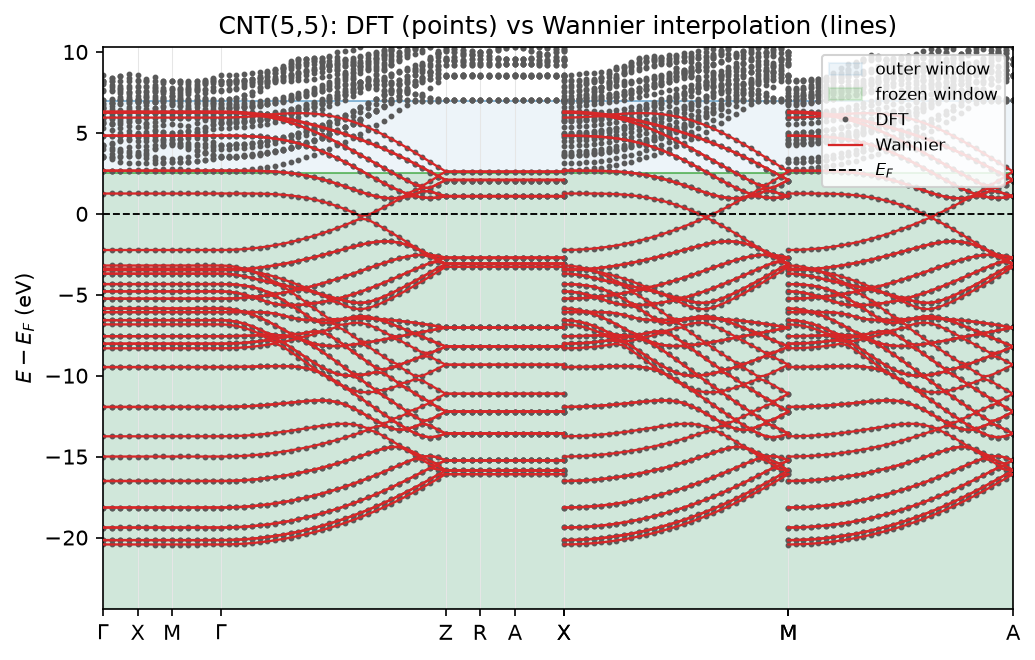

on the Wannier mesh, inside the frozen window: max 0.000 meV, rms 0.000 meV over 221 states


In [4]:
from waw.interfaces.ase.structure import band_path
from waw.core.hamiltonian import interpolate_bands
from waw.interfaces.quantum_espresso import bands_along_path
from waw.analysis.bands import mesh_fidelity
from waw.vis import plot_wannierization_windows

E_F = ov['fermi_energy']
bp = band_path(atoms, npoints=120)
xcoords, xspecial, labels = bp.get_linear_kpoint_axis()
bands = interpolate_bands(result.hr, bp.kpts) * HARTREE_TO_EV
try:
    dft_bands = bands_along_path(WORK, 'cnt55', bp.kpts, ncores=NCORES)
except FileNotFoundError as exc:      # charge density not kept in this run dir
    dft_bands = np.full_like(bands, np.nan)
    print(exc)

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
plot_wannierization_windows(
    ax, xcoords, dft_bands, bands,
    outer_window=(-1e3, 6.3), frozen_window=(-1e3, 1.8), fermi_energy=E_F,
    xticks=xspecial, xticklabels=[l.replace('G', r'$\Gamma$') for l in labels])
ax.set_title('CNT(5,5): DFT (points) vs Wannier interpolation (lines)')
plt.tight_layout(); plt.show()

fid = mesh_fidelity(result.hr, ov['kpts'], ov['eig'],
                    window=(-1e3, 1.8), fermi_ev=E_F)
print(f"on the Wannier mesh, inside the frozen window: max {fid['max']:.3f} meV, "
      f"rms {fid['rms']:.3f} meV over {fid['n_states']} states")


### 3. Ballistic (Landauer) transport along the tube
The (5,5) armchair nanotube is metallic — two bands cross the Fermi level — so the transmission at $E_F$ should show that characteristic **two-channel** conductance.

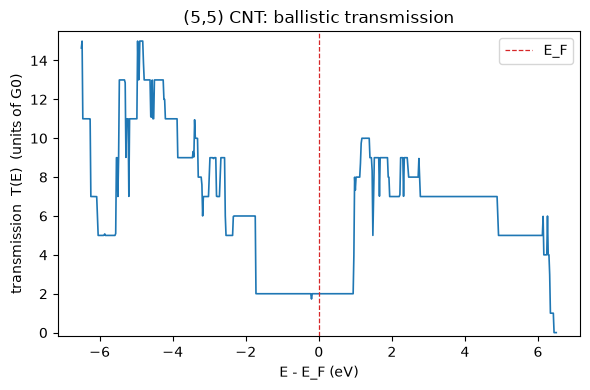

transmission at E_F: T = 2.00 G0  (metallic armchair CNT: expect ~2)


In [5]:
from waw.interfaces.ase.structure import real_lattice
from waw.analysis import transport_bulk
from waw.units import ANG_TO_BOHR, EV_TO_HARTREE

tr = transport_bulk(
    result.hr, real_lattice(atoms), result.centres_bohr, mp_grid=MP_GRID,
    one_dim_axis='z', dist_cutoff=5.5 * ANG_TO_BOHR,
    fermi_energy=ov['fermi_energy'] * EV_TO_HARTREE,
    energy_window=(-6.5 * EV_TO_HARTREE, 6.5 * EV_TO_HARTREE),
    energy_step=0.02 * EV_TO_HARTREE, translate_home_cell=True,
)
E = tr.energies * HARTREE_TO_EV
T = tr.transmission

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(E, T, 'C0', lw=1.2)
ax.axvline(0.0, color='C3', lw=0.9, ls='--', label='E_F')
ax.set_xlabel('E - E_F (eV)'); ax.set_ylabel('transmission  T(E)  (units of G0)')
ax.set_title('(5,5) CNT: ballistic transmission')
ax.set_ylim(-0.2, T.max() + 0.5); ax.legend()
plt.tight_layout(); plt.show()

T_EF = float(T[np.argmin(np.abs(E))])
print(f'transmission at E_F: T = {T_EF:.2f} G0  (metallic armchair CNT: expect ~2)')

The transmission near $E_F$ sits close to the textbook **2 conducting channels** of a metallic armchair nanotube — the two linearly-crossing $\pi$/$\pi^*$ bands near the Fermi level, each contributing one ballistic channel.

**Takeaway.** The same `transport_bulk` Landauer machinery from the aluminium-chain bonus notebook applies unchanged to a real, chemically-detailed 1-D nanostructure — a 50-band disentanglement feeding directly into the ballistic-transport calculation, waw-native throughout.